# EV Adoption Analysis in Ireland
This project aims to analyse and predict electric vehicle (EV) adoption trends in Ireland. 
The analysis focuses on key influencing factors such as fuel prices, and will later incorporate 
additional variables such as charging infrastructure, incentives, and technological advancements.

The goal is to build and evaluate machine learning models to understand which factors most strongly 
affect EV adoption over time.s.

In [2]:
# ================================
# Importing required libraries
# ================================

import pandas as pd        # Data manipulation and analysis
import numpy as np         # Numerical operations
import matplotlib.pyplot as plt  # Data visualisation

In [3]:
# Confirm that the environment is correctly set up
print("Environment setup complete")

Environment setup complete


In [4]:
# Display versions to ensure consistency across environments
print("Pandas version:", pd.__version__)
print("Numpy version:", np.__version__)

Pandas version: 2.2.2
Numpy version: 1.26.4


In [5]:
# ================================
# Load datasets
# ================================

# EV dataset (contains EV sales, stock, charging points, etc.)
ev_df = pd.read_excel('EVDataExplorer2025.xlsx')

# Fuel price dataset (consumer price data including petrol and diesel)
fuel_df = pd.read_csv('CPM12.20260312T150355.csv')

# Transport dataset (to be explored later for additional variables)
transport_df = pd.read_csv('TEM12.20260312T150343.csv')

#Tax dataset (EV tax relief)
eta02 = pd.read_excel("ETA02.20260506T100529.xlsx")

## Exploring the EV Sales Dataset

In this section, we perform an initial exploration of the EV dataset to understand its structure, variables, and data quality before focusing specifically on Ireland.

In [7]:
# Preview the dataset to understand its structure and variables
ev_df.head()

,region_country,category,parameter,mode,powertrain,year,unit,value,Aggregate group
0,World,Projection-STEPS,EV stock,2 and 3 wheelers,BEV,2030,Vehicles,170000000.0,_World
1,World,Projection-STEPS,EV stock,Cars,BEV,2030,Vehicles,150000000.0,_World
2,China,Projection-STEPS,EV stock,2 and 3 wheelers,BEV,2030,Vehicles,91000000.0,Other
3,China,Projection-STEPS,EV stock,Cars,BEV,2030,Vehicles,82000000.0,Other
4,World,Projection-STEPS,EV stock,Cars,PHEV,2030,Vehicles,82000000.0,_World


In [8]:
# Display dataset structure, data types, and non-null counts
ev_df.info()

<class 'pandas.core.frame.DataFrame'>
RangeIndex: 16436 entries, 0 to 16435
Data columns (total 9 columns):
 #   Column           Non-Null Count  Dtype  
---  ------           --------------  -----  
 0   region_country   16436 non-null  object 
 1   category         16436 non-null  object 
 2   parameter        16436 non-null  object 
 3   mode             16436 non-null  object 
 4   powertrain       16436 non-null  object 
 5   year             16436 non-null  int64  
 6   unit             16436 non-null  object 
 7   value            16436 non-null  float64
 8   Aggregate group  16436 non-null  object 
dtypes: float64(1), int64(1), object(7)
memory usage: 1.1+ MB


In [9]:
# Summary statistics for numerical columns (year and value)
ev_df.describe()

,year,value
count,16436.000000,1.643600e+04
mean,2018.852336,2.678267e+05
std,4.271488,3.325613e+06
min,2010.000000,1.200000e-06
25%,2016.000000,1.000000e+00
50%,2019.000000,4.900000e+01
75%,2022.000000,2.500000e+03
max,2030.000000,1.700000e+08


In [10]:
# Check for missing values across all columns
ev_df.isnull().sum()

region_country     0
category           0
parameter          0
mode               0
powertrain         0
year               0
unit               0
value              0
Aggregate group    0
dtype: int64

No missing values are present in the dataset, indicating it is clean and suitable for analysis.

#### Initial Global Trend (Unfiltered Data)

This plot shows EV values across all regions and categories. 
However, it is not meaningful for analysis because it mixes multiple countries, vehicle types, and projections.

A more focused dataset is required.

In [13]:
# Filter dataset for Ireland only (all parameters and vehicle types)
ireland_data = ev_df[ev_df['region_country'] == 'Ireland']

# Preview filtered data
ireland_data.head()

,region_country,category,parameter,mode,powertrain,year,unit,value,Aggregate group
2063,Ireland,Historical,EV sales,Cars,BEV,2023,Vehicles,23000.0,Other
2284,Ireland,Historical,EV sales,Cars,BEV,2024,Vehicles,17000.0,Other
2334,Ireland,Historical,EV sales,Cars,BEV,2022,Vehicles,16000.0,Other
2495,Ireland,Historical,EV sales,Cars,PHEV,2024,Vehicles,13000.0,Other
2704,Ireland,Historical,EV sales,Cars,PHEV,2023,Vehicles,10000.0,Other


In [14]:
# Explore unique values to understand dataset dimensions
ev_df['parameter'].unique()   # What is being measured (sales, stock, charging points, etc.)
ev_df['mode'].unique()       # Vehicle types
ev_df['powertrain'].unique() # Technology type (BEV, PHEV, etc.)

array(['BEV', 'PHEV', 'Publicly available slow',
       'Publicly available fast', 'EV', 'FCEV'], dtype=object)

The dataset contains multiple parameters (e.g., EV sales, stock, charging points), 
different vehicle types, and multiple powertrain technologies. 

For this project, we focus specifically on:
- EV sales
- Cars only
- BEV (Battery Electric Vehicles)

In [16]:
# Filter dataset to focus on:
# - Ireland
# - EV sales only
# - Cars (exclude buses, vans, etc.)
# - BEV (Battery Electric Vehicles)

ireland_ev = ev_df[
    (ev_df['region_country'] == 'Ireland') &
    (ev_df['parameter'] == 'EV sales') &
    (ev_df['mode'] == 'Cars') &
    (ev_df['powertrain'] == 'BEV')
]

In [17]:
# Sort data chronologically for time series analysis
ireland_ev = ireland_ev.sort_values(by='year')

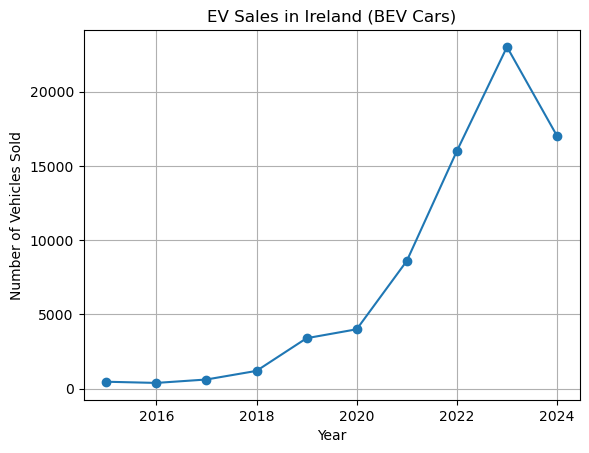

In [18]:
# Plot EV sales trend in Ireland over time
plt.plot(ireland_ev['year'], ireland_ev['value'], marker='o')

plt.title('EV Sales in Ireland (BEV Cars)')
plt.xlabel('Year')
plt.ylabel('Number of Vehicles Sold')

plt.grid()
plt.show()

The plot shows a clear upward trend in EV adoption in Ireland, 
with significant growth after 2020, indicating accelerating adoption rates.

In [20]:
# Create separate datasets for BEV and PHEV comparison

bev = ev_df[
    (ev_df['region_country'] == 'Ireland') &
    (ev_df['parameter'] == 'EV sales') &
    (ev_df['mode'] == 'Cars') &
    (ev_df['powertrain'] == 'BEV')
]

phev = ev_df[
    (ev_df['region_country'] == 'Ireland') &
    (ev_df['parameter'] == 'EV sales') &
    (ev_df['mode'] == 'Cars') &
    (ev_df['powertrain'] == 'PHEV')
]

# Sort both datasets
bev = bev.sort_values(by='year')
phev = phev.sort_values(by='year')

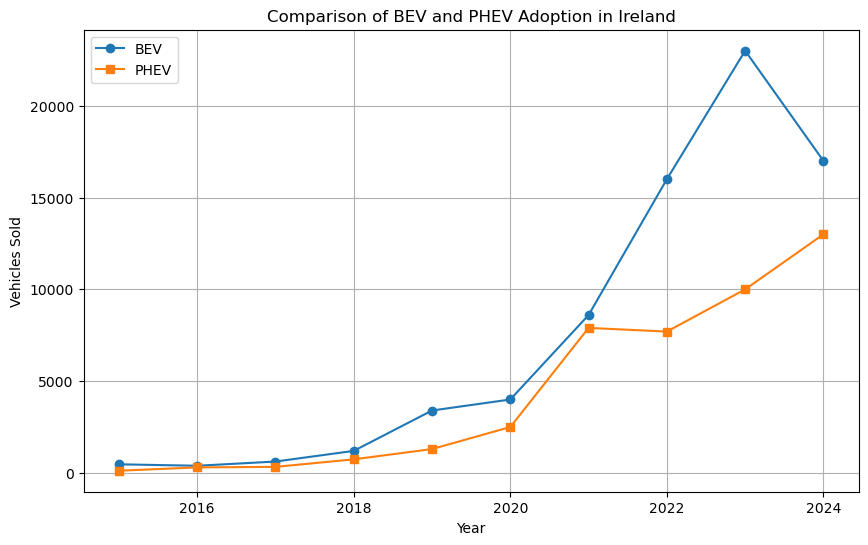

In [21]:
# Compare BEV vs PHEV adoption over time
plt.figure(figsize=(10,6))

plt.plot(bev['year'], bev['value'], marker='o', label='BEV')
plt.plot(phev['year'], phev['value'], marker='s', label='PHEV')

plt.title('Comparison of BEV and PHEV Adoption in Ireland')
plt.xlabel('Year')
plt.ylabel('Vehicles Sold')

plt.legend()
plt.grid()
plt.show()

BEVs show significantly stronger growth compared to PHEVs, 
suggesting a shift towards fully electric vehicles in Ireland.

## EV Adoption Trends in Ireland (BEV vs PHEV)

The graph above illustrates the growth in electric vehicle adoption in Ireland between 2015 and 2024, comparing Battery Electric Vehicles (BEVs) and Plug-in Hybrid Electric Vehicles (PHEVs).

From the data, it is evident that BEVs have experienced significantly faster growth, particularly after 2020, indicating a shift towards fully electric vehicles. While PHEVs have also increased over time, their growth has been more gradual, suggesting they may serve as a transitional technology rather than a long-term solution.

A slight decline in BEV sales is observed in 2024, which may be attributed to external factors such as changes in government incentives, economic conditions, or supply constraints. This highlights the importance of considering external variables when analysing EV adoption trends.

Overall, the data demonstrates a strong upward trend in EV adoption in Ireland, supporting the argument that electric vehicles are becoming increasingly mainstream.ngly mainstream.

### Fuel Prices Dataset Exploration

This section explores fuel price data in Ireland to understand trends in petrol and diesel prices over time, which will later be used as a factor influencing EV adoption.

In [25]:
# Preview fuel dataset to understand its structure and contents
fuel_df.head()

,STATISTIC Label,Month,Consumer Item,UNIT,VALUE
0,National Average Price,2011 December,"White, self raising flour per 2 kg",Euro,NaN
1,National Average Price,2011 December,"Brown, wholemeal flour per 2 kg",Euro,NaN
2,National Average Price,2011 December,"Bread, white sliced pan, large (800g)",Euro,NaN
3,National Average Price,2011 December,"Bread, brown sliced pan, large (800g)",Euro,NaN
4,National Average Price,2011 December,Spaghetti per 500g,Euro,NaN


In [26]:
# Inspect dataset structure, data types, and missing values
fuel_df.info()

<class 'pandas.core.frame.DataFrame'>
RangeIndex: 12996 entries, 0 to 12995
Data columns (total 5 columns):
 #   Column           Non-Null Count  Dtype  
---  ------           --------------  -----  
 0   STATISTIC Label  12996 non-null  object 
 1   Month            12996 non-null  object 
 2   Consumer Item    12996 non-null  object 
 3   UNIT             12996 non-null  object 
 4   VALUE            11679 non-null  float64
dtypes: float64(1), object(4)
memory usage: 507.8+ KB


In [27]:
# Summary statistics for fuel prices
fuel_df.describe()

,VALUE
count,11679.000000
mean,8.407206
std,8.783095
min,0.767000
25%,2.065000
50%,5.037000
75%,11.591500
max,57.321000


In [28]:
# Check for missing values
fuel_df.isnull().sum()

STATISTIC Label       0
Month                 0
Consumer Item         0
UNIT                  0
VALUE              1317
dtype: int64

The dataset contains missing values in the price column, which will need to be handled during preprocessing.

In [30]:
# Filter dataset to include only fuel-related items (petrol and diesel)
fuel_prices = fuel_df[
    fuel_df['Consumer Item'].str.contains('petrol|diesel|fuel', case=False, na=False)
].copy()

fuel_prices.head()

,STATISTIC Label,Month,Consumer Item,UNIT,VALUE
69,National Average Price,2011 December,Diesel per litre,Euro,NaN
70,National Average Price,2011 December,Petrol - unleaded per litre,Euro,NaN
145,National Average Price,2012 January,Diesel per litre,Euro,1.529
146,National Average Price,2012 January,Petrol - unleaded per litre,Euro,1.542
221,National Average Price,2012 February,Diesel per litre,Euro,1.554


In [31]:
# Convert 'Month' column to datetime format and extract year
fuel_prices['Month'] = pd.to_datetime(fuel_prices['Month'], format='%Y %B')
fuel_prices['year'] = fuel_prices['Month'].dt.year

fuel_prices.head()

,STATISTIC Label,Month,Consumer Item,UNIT,VALUE,year
69,National Average Price,2011-12-01,Diesel per litre,Euro,NaN,2011
70,National Average Price,2011-12-01,Petrol - unleaded per litre,Euro,NaN,2011
145,National Average Price,2012-01-01,Diesel per litre,Euro,1.529,2012
146,National Average Price,2012-01-01,Petrol - unleaded per litre,Euro,1.542,2012
221,National Average Price,2012-02-01,Diesel per litre,Euro,1.554,2012


The date column is converted into a datetime format to enable time-based analysis and aggregation by year.ar

In [33]:
# Separate petrol and diesel datasets
petrol = fuel_prices[
    fuel_prices['Consumer Item'].str.contains('petrol', case=False, na=False)
]

diesel = fuel_prices[
    fuel_prices['Consumer Item'].str.contains('diesel', case=False, na=False)
]

Fuel data is split into petrol and diesel categories to compare trends between both fuel types.

The graph shows fluctuations in fuel prices over time, with a noticeable increase around 2021–2022, likely influenced by global economic factors.

These fluctuations are important as rising fuel prices may encourage consumers to switch to electric vehicles.

#### Fuel Prices in Ireland Over Time

This graph illustrates the trend in petrol and diesel prices in Ireland over time. 

Both fuel types follow a similar pattern, with a noticeable decline around 2015–2016, followed by a steady increase. A significant spike is observed around 2021–2022, likely influenced by global economic factors such as supply chain disruptions and geopolitical events.

Understanding these fluctuations is important, as rising fuel prices may influence consumer decisions and encourage a shift towards electric vehicles.

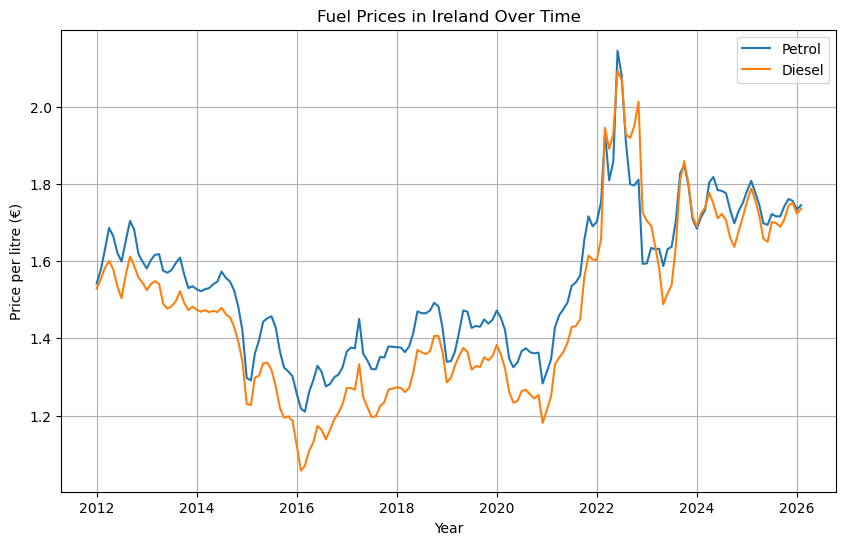

In [37]:
# Plot petrol and diesel price trends over time
plt.figure(figsize=(10,6))

# Line plot for petrol prices
plt.plot(petrol['Month'], petrol['VALUE'], label='Petrol')

# Line plot for diesel prices
plt.plot(diesel['Month'], diesel['VALUE'], label='Diesel')

# Titles and labels
plt.title('Fuel Prices in Ireland Over Time')
plt.xlabel('Year')
plt.ylabel('Price per litre (€)')

# Legend and grid for readability
plt.legend()
plt.grid()

plt.show()

#### Relationship Between Fuel Prices and EV Adoption

This scatter plot shows the relationship between average fuel prices and EV sales in Ireland.

A positive trend can be observed, where higher fuel prices are generally associated with increased EV adoption. This suggests that as traditional fuel becomes more expensive, consumers may be more inclined to switch to electric vehicles.

However, the relationship is not perfectly linear, indicating that other factors (such as government incentives, infrastructure, and technology improvements) also play a significant role.

In [39]:
# Calculate average fuel price per year
fuel_yearly = fuel_prices.groupby('year')['VALUE'].mean().reset_index()

In [40]:
# Prepare EV dataset for merging
ireland_ev = ireland_ev[['year', 'value']]
ireland_ev = ireland_ev.rename(columns={'value': 'ev_sales'})

# Merge EV sales with yearly fuel prices
merged_df = pd.merge(ireland_ev, fuel_yearly, on='year')

In [41]:
# Rename fuel price column for clarity
merged_df = merged_df.rename(columns={'VALUE': 'fuel_price'})

In [42]:
# Inspect merged dataset to confirm correct alignment
merged_df.head()

,year,ev_sales,fuel_price
0,2015,470.0,1.314583
1,2016,390.0,1.213292
2,2017,620.0,1.306917
3,2018,1200.0,1.383625
4,2019,3400.0,1.377250


In [43]:
# Merge EV sales data with yearly fuel price data
merged_df = pd.merge(
    ireland_ev,
    fuel_yearly,
    on='year',
    how='inner'
)

# Rename VALUE column to fuel_price if needed
merged_df = merged_df.rename(columns={'VALUE': 'fuel_price'})

# Preview merged dataset
merged_df.head()

,year,ev_sales,fuel_price
0,2015,470.0,1.314583
1,2016,390.0,1.213292
2,2017,620.0,1.306917
3,2018,1200.0,1.383625
4,2019,3400.0,1.377250


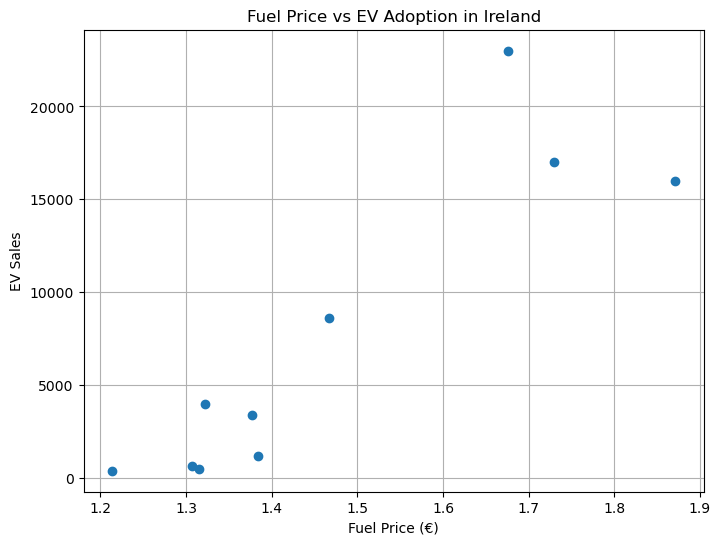

In [44]:
# Scatter plot to examine relationship between fuel prices and EV sales
plt.figure(figsize=(8,6))

# Plot each data point (fuel price vs EV sales)
plt.scatter(merged_df['fuel_price'], merged_df['ev_sales'])

# Titles and labels
plt.title('Fuel Price vs EV Adoption in Ireland')
plt.xlabel('Fuel Price (€)')
plt.ylabel('EV Sales')

# Grid for better visual interpretation
plt.grid()

plt.show()

#### EV Sales and Fuel Prices Over Time

This graph combines EV sales and fuel prices over time using two y-axes, allowing for direct comparison of their trends.

A strong increase in EV adoption is observed after 2020, which coincides with a period of rising fuel prices. This visual comparison supports the hypothesis that fuel price increases may contribute to higher EV adoption.

However, the growth in EV sales is more rapid than fuel price changes alone would explain, suggesting that additional factors such as policy incentives, environmental awareness, and improvements in EV technology are also driving adoption.

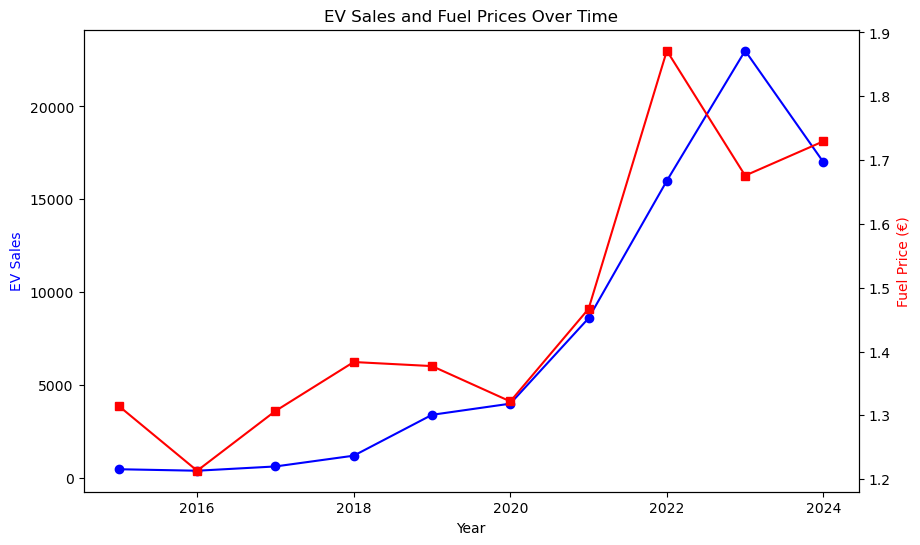

In [46]:
# Dual-axis plot to compare EV sales and fuel prices over time
fig, ax1 = plt.subplots(figsize=(10,6))

# Left axis: EV sales
ax1.set_xlabel('Year')
ax1.set_ylabel('EV Sales', color='blue')
ax1.plot(merged_df['year'], merged_df['ev_sales'], color='blue', marker='o')

# Right axis: Fuel prices
ax2 = ax1.twinx()
ax2.set_ylabel('Fuel Price (€)', color='red')
ax2.plot(merged_df['year'], merged_df['fuel_price'], color='red', marker='s')

# Title
plt.title('EV Sales and Fuel Prices Over Time')

plt.show()

Fuel prices are aggregated by year to align with the EV sales dataset, enabling direct comparison and modelling.

In [48]:
## Relationship Between EV Sales and Fuel Prices

To analyse the relationship between EV adoption and fuel prices, both datasets are merged based on the year.

This allows us to directly compare EV sales with average fuel prices over the same time period.

The scatter plot shows a positive relationship between fuel prices and EV sales.

As fuel prices increase, EV adoption tends to increase as well, suggesting that higher fuel costs may encourage consumers to switch to electric vehicles.

## Visualising relantionship between 1st and 2nd dataset (EV sales and Petrol/diesel price fluctuation)

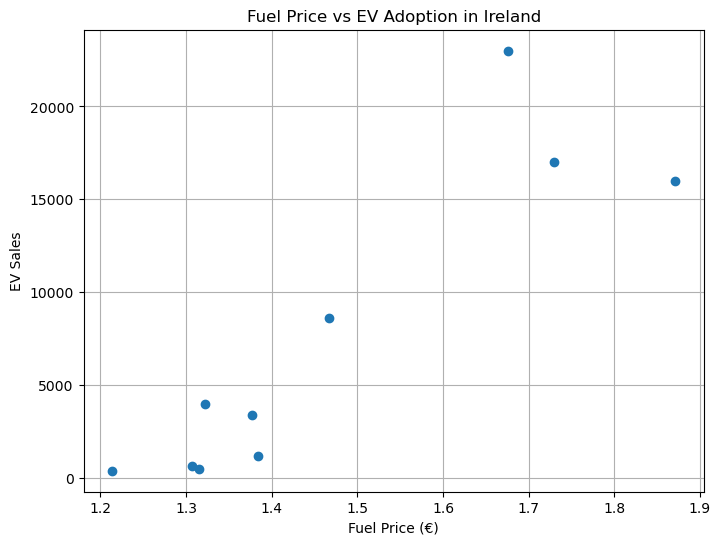

In [52]:
# Select only the relevant columns (year and EV sales)
# Used a copy to avoid modifying the original dataframe
ireland_ev_model = ireland_ev[['year', 'ev_sales']].copy()

# Merge EV sales data with yearly fuel price data using 'year' as the common key
# This allows to analyse both variables over the same time period
merged_df = pd.merge(ireland_ev_model, fuel_yearly, on='year')


# Rename 'VALUE' column (from fuel dataset) to a clearer name
merged_df = merged_df.rename(columns={'VALUE': 'fuel_price'})

# Create a scatter plot to explore the relationship between fuel prices and EV sales
plt.figure(figsize=(8,6))

# Each point represents a year (fuel price vs EV sales)
plt.scatter(merged_df['fuel_price'], merged_df['ev_sales'])

# Add descriptive title and axis labels
plt.title('Fuel Price vs EV Adoption in Ireland')
plt.xlabel('Fuel Price (€)')
plt.ylabel('EV Sales')

# Add grid to improve readability of the plot
plt.grid()

# Display the plot
plt.show()

### Relationship Between Fuel Prices and EV Adoption

The scatter plot above illustrates the relationship between average fuel prices and electric vehicle (EV) adoption in Ireland.

A positive association can be observed, where higher fuel prices tend to correspond with higher EV sales. This suggests that increases in fuel costs may influence consumer behaviour, encouraging a shift towards electric vehicles as a more cost-efficient alternative.

However, it is important to note that this relationship is not strictly causal. Other factors such as government incentives, technological advancements, and the expansion of charging infrastructure also play a significant role in EV adoption.

Overall, the analysis supports the hypothesis that rising fuel prices are one of several contributing factors driving the growth of electric vehicles in Ireland.les.

## Transport Tax Dataset Exploration (ETA02)

This section explores CSO environmental tax data related to transport. 
The purpose is to understand whether broader transport taxation trends can provide useful context for EV adoption in Ireland.

In [55]:
# ================================
# Load ETA02 Environmental Taxes Dataset
# ================================

eta02 = pd.read_excel('ETA02.20260506T100529.xlsx')

# Preview the dataset
eta02.head()

,Unnamed: 0,Unnamed: 1
0,NaN,NaN
1,NaN,NaN
2,NaN,NaN
3,NaN,NaN
4,NaN,NaN


In [56]:
# Check the sheet names inside the ETA02 Excel file
excel_file = pd.ExcelFile('ETA02.20260506T100529.xlsx')

excel_file.sheet_names

['About', 'Unpivoted', 'Pivoted']

In [57]:
# Load the Pivoted sheet instead of the default About sheet
eta02 = pd.read_excel(
    'ETA02.20260506T100529.xlsx',
    sheet_name='Pivoted'
)

# Preview the dataset
eta02.head()

""


In [58]:
# Check structure and column types
eta02.info()

# Display column names
eta02.columns

<class 'pandas.core.frame.DataFrame'>
RangeIndex: 0 entries
Empty DataFrame


RangeIndex(start=0, stop=0, step=1)

In [59]:
# Try loading the Pivoted sheet while skipping metadata rows
eta02 = pd.read_excel(
    'ETA02.20260506T100529.xlsx',
    sheet_name='Pivoted',
    skiprows=10
)

# Preview dataset again
eta02.head(15)

""


In [60]:
# Check unique values in each column to understand categories
for col in eta02.columns:
    print(f"\n{col}")
    print(eta02[col].unique()[:10])

In [61]:
# Load Pivoted sheet with NO headers
raw_eta02 = pd.read_excel(
    'ETA02.20260506T100529.xlsx',
    sheet_name='Pivoted',
    header=None
)

# Display first 30 rows
print(raw_eta02.head(30).to_string())

Empty DataFrame
Columns: []
Index: []


In [62]:
# Load the Unpivoted sheet
eta02 = pd.read_excel(
    'ETA02.20260506T100529.xlsx',
    sheet_name='Unpivoted'
)

# Preview dataset
eta02.head()

,STATISTIC,Statistic Label,TLIST(A1),Year,C03812V04561,Transport taxes,UNIT,VALUE
0,ETA02C01,Tax type,2009,2009,21,Vehicle registration tax,€m,372.99
1,ETA02C01,Tax type,2009,2009,22,Air travel tax,€m,91.91
2,ETA02C01,Tax type,2009,2009,23,National Car Test (NCT) Levy,€m,0.00
3,ETA02C01,Tax type,2009,2009,24,Motor tax (business),€m,264.45
4,ETA02C01,Tax type,2009,2009,25,Motor tax (households),€m,787.36


In [63]:
# Check structure of the correct ETA02 dataset
eta02.info()

# Check available transport tax categories
eta02['Transport taxes'].unique()

<class 'pandas.core.frame.DataFrame'>
RangeIndex: 112 entries, 0 to 111
Data columns (total 8 columns):
 #   Column           Non-Null Count  Dtype  
---  ------           --------------  -----  
 0   STATISTIC        112 non-null    object 
 1   Statistic Label  112 non-null    object 
 2   TLIST(A1)        112 non-null    int64  
 3   Year             112 non-null    int64  
 4   C03812V04561     112 non-null    object 
 5   Transport taxes  112 non-null    object 
 6   UNIT             112 non-null    object 
 7   VALUE            112 non-null    float64
dtypes: float64(1), int64(2), object(5)
memory usage: 7.1+ KB


array(['Vehicle registration tax', 'Air travel tax',
       'National Car Test (NCT) Levy', 'Motor tax (business)',
       'Motor tax (households)', 'Vehicle and driving licence expenses',
       'All Transport Taxes'], dtype=object)

In [64]:
# Filter the most relevant transport tax categories
eta02_relevant = eta02[
    eta02['Transport taxes'].isin([
        'Vehicle registration tax',
        'Motor tax (households)',
        'Motor tax (business)',
        'All Transport Taxes'
    ])
]

eta02_relevant.head()

,STATISTIC,Statistic Label,TLIST(A1),Year,C03812V04561,Transport taxes,UNIT,VALUE
0,ETA02C01,Tax type,2009,2009,21,Vehicle registration tax,€m,372.99
3,ETA02C01,Tax type,2009,2009,24,Motor tax (business),€m,264.45
4,ETA02C01,Tax type,2009,2009,25,Motor tax (households),€m,787.36
6,ETA02C01,Tax type,2009,2009,-,All Transport Taxes,€m,1522.71
7,ETA02C01,Tax type,2010,2010,21,Vehicle registration tax,€m,394.88


### Vehicle Registration Tax Over Time

This visualization explores changes in Vehicle Registration Tax (VRT) revenue over time in Ireland. 
The graph helps provide fiscal and policy context related to transport and vehicle ownership.

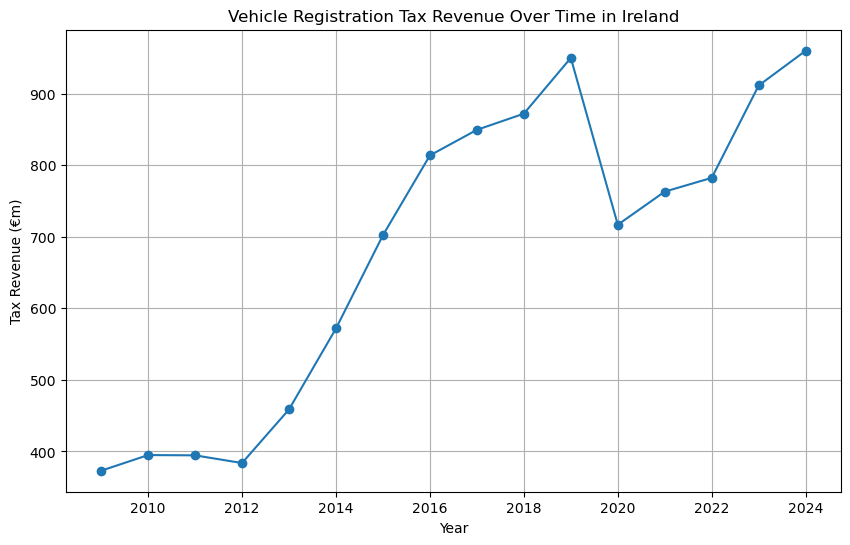

In [66]:
# Filter Vehicle Registration Tax data only
vrt_tax = eta02[
    eta02['Transport taxes'] == 'Vehicle registration tax'
]

# Create the graph
plt.figure(figsize=(10,6))

plt.plot(
    vrt_tax['Year'],
    vrt_tax['VALUE'],
    marker='o'
)

# Titles and labels
plt.title('Vehicle Registration Tax Revenue Over Time in Ireland')
plt.xlabel('Year')
plt.ylabel('Tax Revenue (€m)')

# Grid for readability
plt.grid()

# Show graph
plt.show()

## EV Grant Data Integration

This section manually creates a dataset containing EV purchase grant values in Ireland over time. 
The grant data is included as a policy-related variable to help explore how government incentives may influence EV adoption.

In [68]:
# Create EV Grant Dataset
grant_data = {
    'year': [2011, 2012, 2013, 2014, 2015,
             2016, 2017, 2018, 2019, 2020,
             2021, 2022, 2023, 2024],
    
    'grant_value': [5000, 5000, 5000, 5000, 5000,
                    5000, 5000, 5000, 5000, 5000,
                    5000, 5000, 3500, 3500]
}

# Convert dictionary into dataframe
grant_df = pd.DataFrame(grant_data)

# Preview dataset
grant_df.head()

,year,grant_value
0,2011,5000
1,2012,5000
2,2013,5000
3,2014,5000
4,2015,5000


### EV Grant Values Over Time

This graph visualizes the evolution of EV purchase grants in Ireland and highlights changes in government incentives over time.

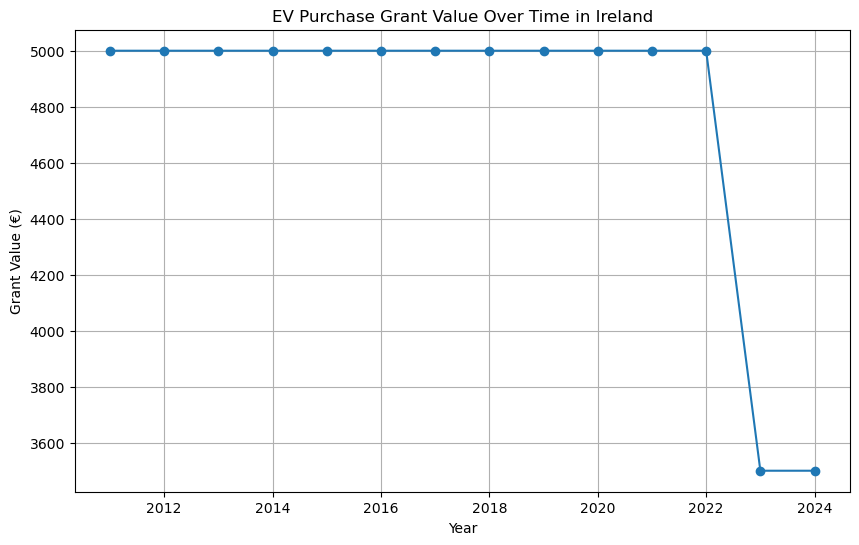

In [70]:
# Plot EV grant values over time
plt.figure(figsize=(10,6))

plt.plot(
    grant_df['year'],
    grant_df['grant_value'],
    marker='o'
)

# Titles and labels
plt.title('EV Purchase Grant Value Over Time in Ireland')
plt.xlabel('Year')
plt.ylabel('Grant Value (€)')

# Grid for readability
plt.grid()

# Show graph
plt.show()

## Final Modeling Dataset

This section merges EV adoption, fuel price, and EV grant data into a single dataset that will be used for machine learning and predictive analysis.

In [72]:
# ================================
# Create Final Modeling Dataset
# ================================

# Merge EV/fuel dataset with grant dataset
final_model_df = pd.merge(
    merged_df,
    grant_df,
    on='year',
    how='left'
)

# Preview final dataset
final_model_df.head()

,year,ev_sales,fuel_price,grant_value
0,2015,470.0,1.314583,5000
1,2016,390.0,1.213292,5000
2,2017,620.0,1.306917,5000
3,2018,1200.0,1.383625,5000
4,2019,3400.0,1.377250,5000


In [73]:
# Check structure of final modeling dataset
final_model_df.info()

<class 'pandas.core.frame.DataFrame'>
RangeIndex: 10 entries, 0 to 9
Data columns (total 4 columns):
 #   Column       Non-Null Count  Dtype  
---  ------       --------------  -----  
 0   year         10 non-null     int64  
 1   ev_sales     10 non-null     float64
 2   fuel_price   10 non-null     float64
 3   grant_value  10 non-null     int64  
dtypes: float64(2), int64(2)
memory usage: 452.0 bytes


In [74]:
# Summary statistics
final_model_df.describe()

,year,ev_sales,fuel_price,grant_value
count,10.00000,10.000000,10.000000,10.000000
mean,2019.50000,7468.000000,1.466117,4700.000000
std,3.02765,8299.980991,0.217389,632.455532
min,2015.00000,390.000000,1.213292,3500.000000
25%,2017.25000,765.000000,1.316406,5000.000000
50%,2019.50000,3700.000000,1.380438,5000.000000
75%,2021.75000,14150.000000,1.623552,5000.000000
max,2024.00000,23000.000000,1.871417,5000.000000


# Model 1- Linear Regression (Fuel --> EV Sales)

Intercept: -37327.11259017257
Slope (Coefficient): [29690.54431477]
Mean Squared Error: 58059141.493623674
R² Score: 0.3566854128130341


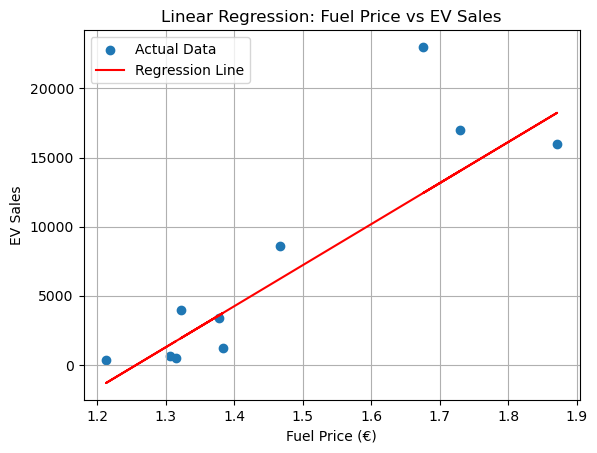

In [76]:
# Preview merged dataset to confirm structure
merged_df.head()

# Ensure dataset is sorted by year (important for time-based analysis)
merged_df = merged_df.sort_values(by='year')

# Independent variable (input feature)
# In this model, use fuel price as the only predictor
X = merged_df[['fuel_price']]

# y = dependent variable (target)
# This is what the project is trying to predict (EV sales)
y = merged_df['ev_sales']


# Train-test split
from sklearn.model_selection import train_test_split

# Split the data into training (80%) and testing (20%) sets
# random_state ensures reproducibility of results
X_train, X_test, y_train, y_test = train_test_split(
    X, y, test_size=0.2, random_state=7
)

# Train model

from sklearn.linear_model import LinearRegression

# Create linear regression model
model = LinearRegression()

# Fit model using training data (learn relationship between X and y)
model.fit(X_train, y_train)


# Predict EV sales using test data
y_pred = model.predict(X_test)


from sklearn.metrics import mean_squared_error, r2_score

# The coefficient represents how much EV sales are expected to change
# for each €1 increase in fuel price
# Display model parameters for interpretation
print("Intercept:", model.intercept_)
print("Slope (Coefficient):", model.coef_)

# Mean Squared Error (MSE)
# Measures average squared difference between predicted and actual values
mse = mean_squared_error(y_test, y_pred)

# R² Score
# Measures how well the model explains variation in EV sales (0 = poor, 1 = perfect fit)
r2 = r2_score(y_test, y_pred)

# Print evaluation results
print("Mean Squared Error:", mse)
print("R² Score:", r2)

# Scatter plot of actual data points
plt.scatter(X, y, label='Actual Data')

# Plot regression line (model predictions across all X values)
plt.plot(X, model.predict(X), color='red', label='Regression Line')

# Labels and title
plt.xlabel('Fuel Price (€)')
plt.ylabel('EV Sales')
plt.title('Linear Regression: Fuel Price vs EV Sales')

# Add legend and grid
plt.legend()
plt.grid()

# Display plot
plt.show()

# NOTE:
# This model uses only one feature (fuel price), so it may not fully capture
# all factors influencing EV adoption (e.g., incentives, infrastructure, technology)

### Model 1 Results: Fuel Price → EV Sales

The linear regression model indicates a positive relationship between fuel prices and EV adoption.

The model coefficient suggests that increases in fuel prices are associated with higher EV sales. This aligns with the expectation that higher fuel costs may encourage consumers to switch to electric vehicles.

However, the model achieves an R² score of approximately 0.36, indicating that fuel price alone explains only a moderate proportion of the variation in EV sales.

This suggests that while fuel prices are a contributing factor, other variables such as government incentives, charging infrastructure, and technological advancements are also likely to play a significant role.

Additionally, both fuel prices and EV sales show upward trends over time, which may contribute to the observed relationship. Therefore, caution should be taken when interpreting this as a purely causal effect.els.icles.

# Model 2: Multiple Linear Regression

In [79]:
# Ensure dataset is sorted by year (important for time-based features)
merged_df = merged_df.sort_values(by='year')

# Define variables
# X = independent variables (multiple features)
# - fuel_price → economic factor
# - year → captures time trend / growth of EV adoption
X = merged_df[['fuel_price', 'year']]

# y = dependent variable (target)
# EV sales we want to predict
y = merged_df['ev_sales']


# Train-test split
from sklearn.model_selection import train_test_split

# Split data into training (80%) and testing (20%)
# random_state ensures consistent results across runs
X_train, X_test, y_train, y_test = train_test_split(
    X, y, test_size=0.2, random_state=7
)

# Train model
from sklearn.linear_model import LinearRegression

# Create regression model
model = LinearRegression()

# Fit model to training data
# The model learns how BOTH features influence EV sales
model.fit(X_train, y_train)

# Predict EV sales on test dataset
y_pred = model.predict(X_test)


# Model evaluation
from sklearn.metrics import mean_squared_error, r2_score

# Mean Squared Error (MSE)
# Measures prediction error (lower is better)
mse = mean_squared_error(y_test, y_pred)

# R² Score
# Measures how well the model explains EV sales variation
# Closer to 1 = better model
r2 = r2_score(y_test, y_pred)

print("Mean Squared Error:", mse)
print("R² Score:", r2)

# Model interpretation
# Intercept = baseline EV sales when all features are 0
print("Intercept:", model.intercept_)

# Coefficients = impact of each feature
# [fuel_price coefficient, year coefficient]
print("Coefficients:", model.coef_)

# Interpretation:
# - fuel_price coefficient → change in EV sales per €1 increase
# - year coefficient → yearly growth effect in EV adoption


# -------------------------------
# Notes / limitations
# -------------------------------

# This model improves on Model 1 by including time (year), which captures underlying growth trends in EV adoption. However, additional factors such as incentives and infrastructure are still not included.

Mean Squared Error: 41965203.515416175
R² Score: 0.5350115953970507
Intercept: -2086636.0581787473
Coefficients: [17462.50068311  1023.84186857]


### Model 2 Analysis

Model 2 extends the initial linear regression by incorporating both fuel price and year as independent variables to predict EV sales in Ireland. This allows the model to capture not only economic influences but also the underlying time-based growth in EV adoption.

The R² score improved from approximately 0.36 in Model 1 to around 0.54 in Model 2, indicating that the model now explains a greater proportion of the variation in EV sales. This demonstrates that including a time variable significantly improves model performance, as EV adoption is strongly influenced by long-term trends.

The coefficient for fuel price remains positive, suggesting that increases in fuel costs are associated with higher EV sales, likely due to consumers seeking more cost-efficient alternatives. However, this relationship should be interpreted while holding other variables constant.

The year variable also has a positive coefficient, indicating a consistent upward trend in EV adoption over time. This reflects broader structural factors such as technological advancements, increased government support, improved charging infrastructure, and growing environmental awareness.

Despite the improved performance, the model still has limitations. An R² value of 0.54 suggests that a substantial portion of the variation in EV sales remains unexplained. This highlights the importance of additional factors not included in the model, such as government incentives, charging infrastructure availability, vehicle costs, and battery technology improvements.

Overall, Model 2 provides a more realistic and comprehensive representation of EV adoption compared to Model 1, but further enhancements could be achieved by incorporating additional relevanles.vements.

# Model 3: Multiple Linear Regression with Fuel Price, Year and Grant Value

This model expands on Model 2 by adding EV grant value as an additional independent variable. The purpose is to test whether government incentives improve the model’s ability to predict EV sales in Ireland.

The features used in this model are:

- fuel_price: average yearly petrol/diesel price
- year: captures long-term EV adoption trends
- grant_value: represents government financial support for EV purchases

The target variable remains EV sales.

In [82]:
# Model 3: Fuel Price + Year + Grant Value

# Ensure final dataset is sorted by year
final_model_df = final_model_df.sort_values(by='year')

# Define independent variables
# These are the factors used to predict EV sales
X = final_model_df[['fuel_price', 'year', 'grant_value']]

# Define dependent variable
# This is the target the model is trying to predict
y = final_model_df['ev_sales']

# Import train-test split
from sklearn.model_selection import train_test_split

# Split dataset into training and testing sets
# 80% of the data is used for training, 20% for testing
X_train, X_test, y_train, y_test = train_test_split(
    X, y, test_size=0.2, random_state=7
)

# Import Linear Regression model
from sklearn.linear_model import LinearRegression

# Create the model
model_3 = LinearRegression()

# Train the model using the training data
model_3.fit(X_train, y_train)

# Predict EV sales using the test data
y_pred = model_3.predict(X_test)

# Import evaluation metrics
from sklearn.metrics import mean_squared_error, r2_score

# Calculate model performance
mse = mean_squared_error(y_test, y_pred)
r2 = r2_score(y_test, y_pred)

# Display results
print("Mean Squared Error:", mse)
print("R² Score:", r2)

# Display model parameters
print("Intercept:", model_3.intercept_)
print("Coefficients:", model_3.coef_)

# Show coefficients beside feature names for easier interpretation
coefficients_df = pd.DataFrame({
    'Feature': X.columns,
    'Coefficient': model_3.coef_
})

coefficients_df

Mean Squared Error: 30209100.130862743
R² Score: 0.6652731287439031
Intercept: -1562466.362772879
Coefficients: [ 1.86936652e+04  7.67198265e+02 -1.62103435e+00]


,Feature,Coefficient
0,fuel_price,18693.665198
1,year,767.198265
2,grant_value,-1.621034


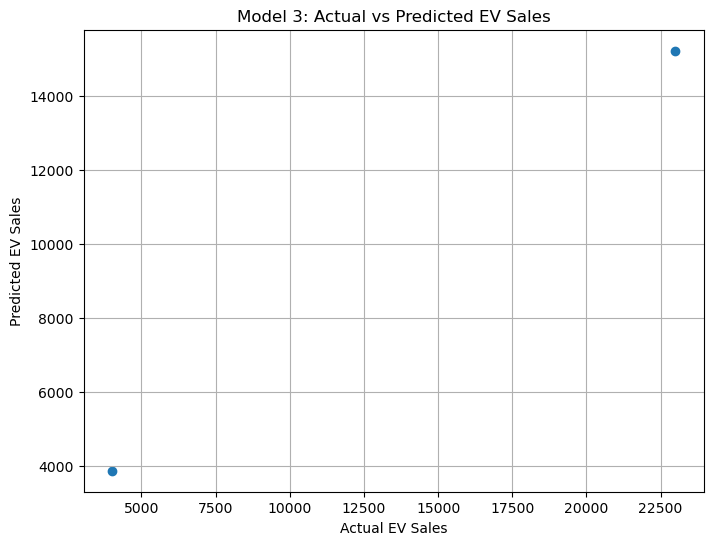

In [83]:
# Plot actual vs predicted EV sales

plt.figure(figsize=(8, 6))

plt.scatter(y_test, y_pred)

plt.xlabel('Actual EV Sales')
plt.ylabel('Predicted EV Sales')
plt.title('Model 3: Actual vs Predicted EV Sales')

plt.grid()

plt.show()

## Model 3 Analysis

Model 3 used fuel price, year, and grant value to predict EV sales. The R² score was approximately 0.67, meaning the model explained around 67% of the variation in the test data.

However, this result should be interpreted carefully because the dataset is very small and the test set only contains a small number of years. The actual vs predicted graph only shows two points because 20% of the dataset was used for testing.

The model suggests that adding grant value provides another useful policy-related variable, but it does not prove that grants directly caused changes in EV sales.